In [1]:
# ===============================
# 1. Imports
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import shap
import matplotlib.pyplot as plt

/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("../dataset/Heart_disease_cleveland_new.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [3]:
# ===============================
# 3. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# ===============================
# 4. Scaling
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# ===============================
# 5. Random Forest Model
# ===============================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# ===============================
# 6. Evaluation
# ===============================
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8852459016393442
F1 Score: 0.8852459016393442
ROC-AUC: 0.9512987012987013


SHAP shape: (61, 13)


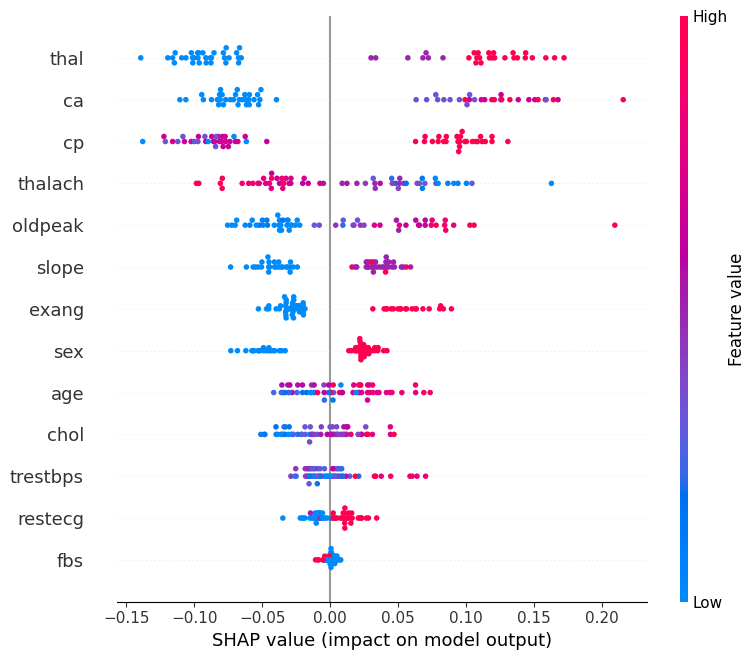

In [16]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_scaled).values

# 🔥 FIX: select class 1
shap_values_class1 = shap_values[:, :, 1]

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("SHAP shape:", shap_values_class1.shape)  # should be (61, 13)

# ===============================
# 8. SHAP Summary Plot
# ===============================
shap.summary_plot(shap_values_class1, X_test_df)

In [17]:
# ===============================
# 9. Feature Importance
# ===============================
mean_abs_shap = np.mean(np.abs(shap_values_class1), axis=0)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

print(feature_importance)

     feature  mean_abs_shap
12      thal       0.101445
11        ca       0.094827
2         cp       0.091610
7    thalach       0.052608
9    oldpeak       0.050183
10     slope       0.039049
8      exang       0.038964
1        sex       0.033297
0        age       0.024409
4       chol       0.020808
3   trestbps       0.015824
6    restecg       0.011987
5        fbs       0.002661


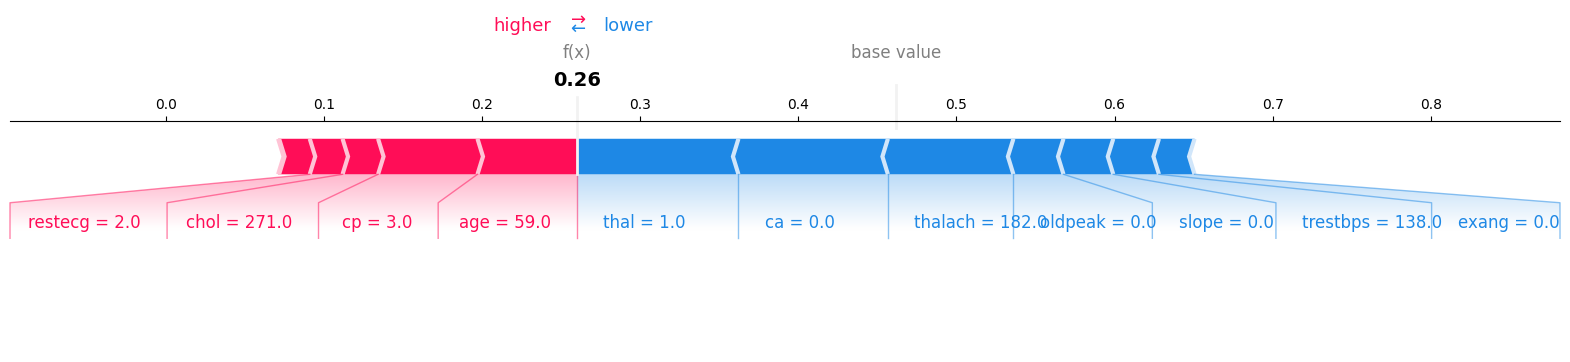

In [20]:
# ===============================
# 10. Force Plot
# ===============================

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True
)